<a href="https://colab.research.google.com/github/ridahafeez786/Lab-work-1/blob/main/StockMarkerRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving stock_market_data.csv to stock_market_data.csv


        Date Ticker Asset_Type      Sector Market_Cap_Tier    Open    High  \
0 2023-01-02   AAPL      Stock  Technology       Large-Cap  130.68  131.83   
1 2023-01-03   AAPL      Stock  Technology       Large-Cap  131.18  132.82   
2 2023-01-04   AAPL      Stock  Technology       Large-Cap  129.10  133.64   
3 2023-01-05   AAPL      Stock  Technology       Large-Cap  131.95  137.95   
4 2023-01-06   AAPL      Stock  Technology       Large-Cap  136.08  137.16   

      Low   Close   Volume  
0  130.07  131.22  3606305  
1  129.33  130.97  1718599  
2  128.03  132.55  4018645  
3  130.29  136.23  4547883  
4  134.68  135.75  4393131  
(2395, 10)
Date               datetime64[ns]
Ticker                     object
Asset_Type                 object
Sector                     object
Market_Cap_Tier            object
Open                      float64
High                      float64
Low                       float64
Close                     float64
Volume                      int64
dtype:

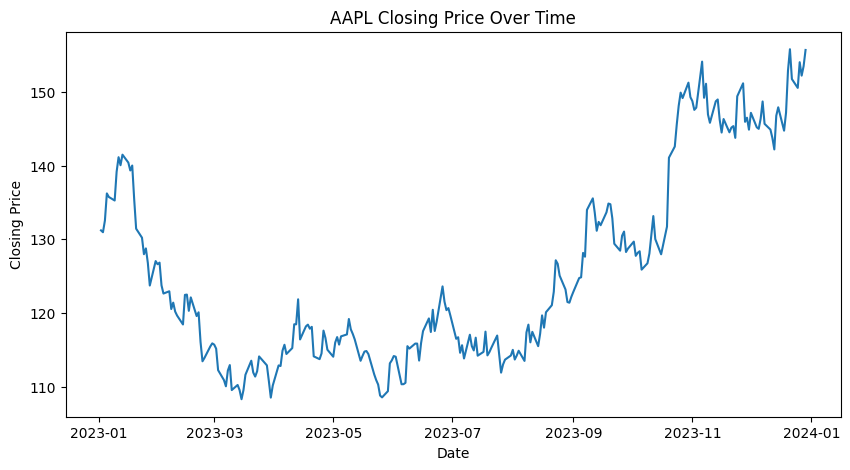

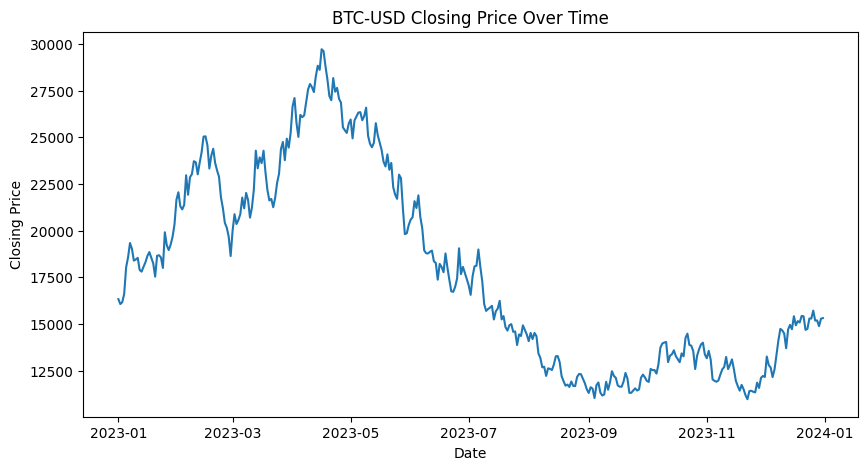

          Date  Actual   Predicted
208 2023-10-19  141.07  131.091860
209 2023-10-20  142.58  139.142648
210 2023-10-23  145.55  141.009756
211 2023-10-24  148.10  143.725640
212 2023-10-25  149.89  146.273345
213 2023-10-26  149.15  148.223047
214 2023-10-27  151.24  148.059630
215 2023-10-30  149.28  149.632915
216 2023-10-31  148.74  148.568190
217 2023-11-01  147.55  147.872292


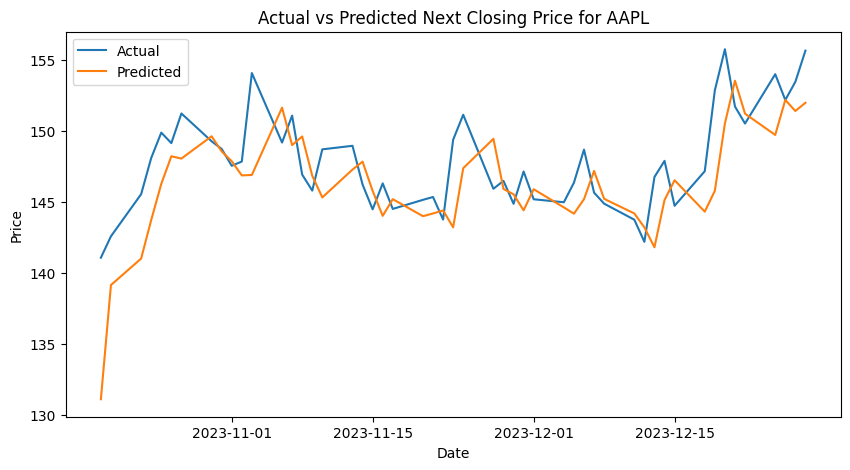

MAE: 2.4708736858755134
RMSE: 3.222232869508256
R² Score: 0.11052684295450677


In [10]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load data
df = pd.read_csv("stock_market_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Step 3: Explore data
print(df.head())
print(df.shape)
print(df.dtypes)
print(df["Ticker"].unique())

# Step 4: Plot one stock and one crypto
aapl = df[df["Ticker"] == "AAPL"]
btc = df[df["Ticker"] == "BTC-USD"]

plt.figure(figsize=(10,5))
plt.plot(aapl["Date"], aapl["Close"])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(btc["Date"], btc["Close"])
plt.title("BTC-USD Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

# Step 5: Choose one asset
asset = df[df["Ticker"] == "AAPL"].copy()
asset = asset.sort_values("Date")

# Step 6: Create target variable
asset["Next_Close"] = asset["Close"].shift(-1)

# Step 7: Create features
asset["Daily_Return"] = asset["Close"].pct_change()
asset["MA_5"] = asset["Close"].rolling(window=5).mean()
asset["Previous_Close"] = asset["Close"].shift(1)

# Step 8: Drop missing rows
asset = asset.dropna()

# Step 9: Select features and target
features = ["Daily_Return", "MA_5", "Previous_Close"]

X = asset[features]
y = asset["Next_Close"]

# Step 10: Train-test split without shuffling
split_index = int(len(asset) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Step 11: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 12: Predict
y_pred = model.predict(X_test)

# Step 13: Actual vs Predicted table
results = pd.DataFrame({
    "Date": asset.iloc[split_index:]["Date"],
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

# Step 14: Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(results["Date"], results["Actual"], label="Actual")
plt.plot(results["Date"], results["Predicted"], label="Predicted")
plt.title("Actual vs Predicted Next Closing Price for AAPL")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Step 15: Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
